# Telco customer churn: exploratory analysis

A reproducible look at the training partition only. The stratified holdout is reserved for final evaluation. Run training from the repository root before the final comparison cells. Numeric conversion is stateless; imputation, scaling and category encoding are learned inside each training fold, not in this notebook.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from telco_churn.data import load_split, clean_features
ROOT = Path.cwd() if Path("data/telco.csv").exists() else Path.cwd().parent
X_train, X_test, y_train, y_test = load_split(ROOT / "data/telco.csv")
X = clean_features(X_train)
print(f"Training rows: {len(X_train):,}; reserved holdout: {len(X_test):,}")
display(pd.DataFrame({"dtype": X.dtypes.astype(str), "missing": X.isna().sum(), "unique": X.nunique()}))

Training rows: 5,634; reserved holdout: 1,409


,dtype,missing,unique
SeniorCitizen,int64,0,2
tenure,int64,0,73
MonthlyCharges,float64,0,1489
TotalCharges,float64,8,5275
gender,object,0,2
Partner,object,0,2
Dependents,object,0,2
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3


## Missing values and data types
`TotalCharges` is a string in the source CSV, including whitespace-only entries. Conversion produces missing values which are median-imputed inside the numeric pipeline. Categorical missing values are imputed with the training-fold mode. Unknown inference categories are ignored by the encoder, not fitted on new data. The customer identifier is not a predictive feature.

In [2]:
display(X.describe().round(2))
print("Blank/missing TotalCharges in training:", int(X.TotalCharges.isna().sum()))
print("Categorical fields:", list(X.select_dtypes("object").columns))

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.00,5634.00,5634.00,5626.00
mean,0.16,32.49,64.93,2302.60
std,0.37,24.57,30.14,2279.17
min,0.00,0.00,18.40,18.85
25%,0.00,9.00,35.66,407.28
50%,0.00,29.00,70.50,1398.12
75%,0.00,55.00,90.00,3838.61
max,1.00,72.00,118.75,8684.80


Blank/missing TotalCharges in training: 8
Categorical fields: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


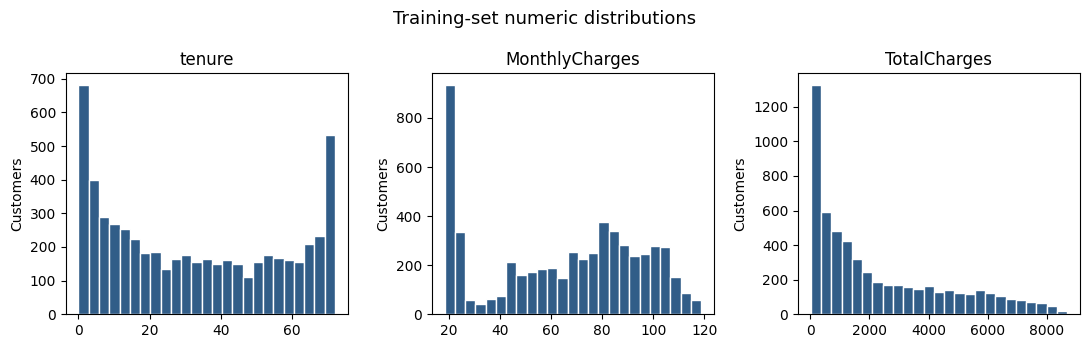

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    ax.hist(X[col].dropna(), bins=25, color="#315d88", edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel("Customers")
fig.suptitle("Training-set numeric distributions", fontsize=13)
fig.tight_layout()
(ROOT / "reports").mkdir(exist_ok=True)
fig.savefig(ROOT / "reports/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Class imbalance and contract patterns
Both models use balanced class weights. No resampling is performed before splitting or cross-validation. A majority-class classifier can appear accurate while finding no churners; ROC-AUC, average precision and F1 give more useful views. Average precision is the reported PR-AUC summary, not trapezoidal integration of the curve. Contract patterns below are associations, not causal findings.

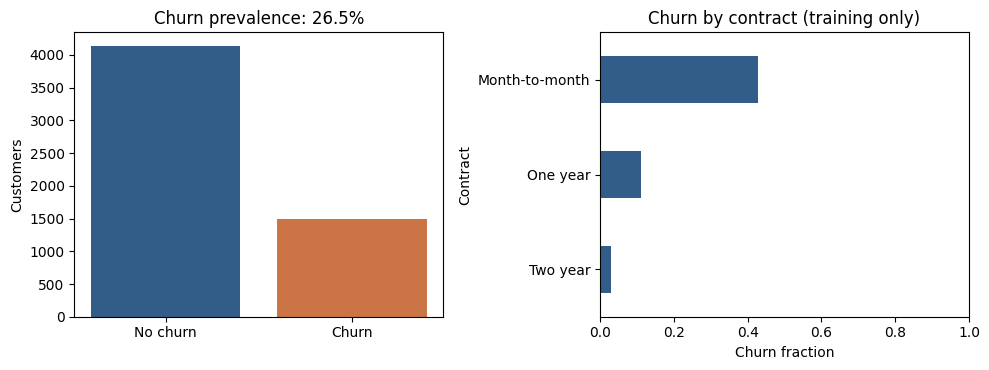

Always predicting no churn yields 73.5% training accuracy but 0 recall.


In [4]:
counts = y_train.value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].bar(["No churn", "Churn"], counts.values, color=["#315d88", "#cb7546"])
axes[0].set_ylabel("Customers")
axes[0].set_title(f"Churn prevalence: {y_train.mean():.1%}")
contract = X.assign(Churn=y_train).groupby("Contract").Churn.mean().sort_values()
contract.plot.barh(ax=axes[1], color="#315d88")
axes[1].set_xlabel("Churn fraction")
axes[1].set_xlim(0, 1)
axes[1].set_title("Churn by contract (training only)")
fig.tight_layout()
fig.savefig(ROOT / "reports/churn_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Always predicting no churn yields {1-y_train.mean():.1%} training accuracy but 0 recall.")

## Model comparison
Training uses 5-fold stratified CV. Random Forest searches eight configurations, refitting the best by CV average precision. Final selection between Logistic Regression and the tuned forest also uses training CV average precision. The holdout is not used for tuning, threshold selection or model choice. Tuned CV estimates are optimistic because they also select parameters; the untouched holdout is the better final estimate. Small score differences should not be treated as decisive without uncertainty estimates.

In [5]:
report = json.loads((ROOT / "artifacts/metrics.json").read_text())
rows = []
for result in report["results"]:
    rows.append({"model": result["model"], **{f"CV {k}":v for k,v in result["cv"].items()},
                 **{f"Holdout {k}":v for k,v in result["holdout"].items() if k != "confusion_matrix"}})
display(pd.DataFrame(rows).set_index("model").round(4))
print("Selected using training CV:", report["selected_model"])
print("Forest settings:", report["forest_best_params"])
print("Decision threshold:", report["decision_threshold"])
for result in report["results"]:
    print(result["model"], "holdout confusion matrix [TN, FP; FN, TP]:", result["holdout"]["confusion_matrix"])

,CV roc_auc,CV pr_auc_ap,CV f1,Holdout roc_auc,Holdout pr_auc_ap,Holdout f1,Holdout precision,Holdout recall
model,,,,,,,,
logistic_regression,0.8459,0.6600,0.6279,0.8413,0.6326,0.6136,0.5043,0.7834
random_forest_tuned,0.8480,0.6643,0.6324,0.8449,0.6523,0.6332,0.5351,0.7754


Selected using training CV: random_forest_tuned
Forest settings: {'model__max_depth': 6, 'model__max_features': 0.7, 'model__min_samples_leaf': 2}
Decision threshold: 0.5
logistic_regression holdout confusion matrix [TN, FP; FN, TP]: [[747, 288], [81, 293]]
random_forest_tuned holdout confusion matrix [TN, FP; FN, TP]: [[783, 252], [84, 290]]


## Practical limitations

- This is one static historical dataset, not evidence of future business performance.
- The 0.5 threshold is fixed in advance. Balanced class weighting changes the effective class prior, so output probabilities should not be presented as calibrated risk scores.
- Median imputation is a pragmatic baseline for the few missing charges. Business-specific treatment needs more context.
- No client data, production deployment, causal interpretation or live monitoring is claimed.